# End-to-End Incident-Priority Classifier

This notebook is executable from the chapter directory.

## Project goal

Build a temporal, leakage-aware, calibrated incident P1 classifier. Select the threshold on validation data and evaluate the frozen policy once on the final test period.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

REPO = Path.cwd().parents[1]
sys.path.insert(0, str(REPO / "src"))

from ml_foundations.calibration import expected_calibration_error
from ml_foundations.data import FEATURE_COLUMNS, temporal_split
from ml_foundations.metrics import binary_metrics, threshold_sweep

ASSETS = Path.cwd() / "assets"
REPORTS = Path.cwd() / "reports"
ASSETS.mkdir(exist_ok=True)
REPORTS.mkdir(exist_ok=True)

## Load and audit data

In [2]:
data = pd.read_csv(REPO / "data/incident_priority_synthetic.csv", parse_dates=["timestamp"])
print(data.head())
print("Shape:", data.shape)
print("Positive rate:", round(data["is_p1"].mean(), 5))
print("Missing values:", int(data.isna().sum().sum()))
print("Time range:", data["timestamp"].min(), "to", data["timestamp"].max())

  incident_id           timestamp  ...  monitoring_confidence  is_p1
0  INC-000001 2024-01-01 00:00:00  ...                0.58850      0
1  INC-000002 2024-01-01 03:00:00  ...                0.83087      0
2  INC-000003 2024-01-01 06:00:00  ...                0.66829      0
3  INC-000004 2024-01-01 09:00:00  ...                0.86801      0
4  INC-000005 2024-01-01 12:00:00  ...                0.66226      0

[5 rows x 11 columns]
Shape: (2400, 11)
Positive rate: 0.01958
Missing values: 0
Time range: 2024-01-01 00:00:00 to 2024-10-26 21:00:00


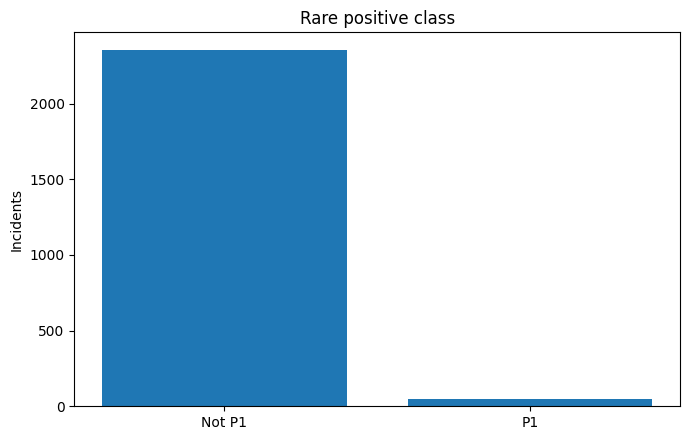

In [3]:
plt.figure(figsize=(7, 4.5))
counts = data["is_p1"].value_counts().sort_index()
plt.bar(["Not P1", "P1"], counts.values)
plt.ylabel("Incidents")
plt.title("Rare positive class")
plt.tight_layout()
plt.savefig(ASSETS / "class_balance.png", dpi=160)
plt.show()

## Temporal split

The newest 20 percent remains locked for final evaluation.

In [4]:
train, validation, test = temporal_split(data)
for name, frame in [("train", train), ("validation", validation), ("test", test)]:
    print(
        name,
        frame.shape,
        "positive rate=", round(frame["is_p1"].mean(), 5),
        "range=", frame["timestamp"].min(), "to", frame["timestamp"].max(),
    )

train (1440, 11) positive rate= 0.01528 range= 2024-01-01 00:00:00 to 2024-06-28 21:00:00
validation (480, 11) positive rate= 0.02708 range= 2024-06-29 00:00:00 to 2024-08-27 21:00:00
test (480, 11) positive rate= 0.025 range= 2024-08-28 00:00:00 to 2024-10-26 21:00:00


## Baselines

Compare a no-alert baseline with a simple critical-service rule before evaluating ML.

In [5]:
no_alert = np.zeros(len(validation), dtype=int)
critical_rule = (validation["service_criticality"].to_numpy() >= 5).astype(int)
print("No-alert baseline:", binary_metrics(validation["is_p1"], no_alert))
print("Criticality rule:", binary_metrics(validation["is_p1"], critical_rule))

No-alert baseline: {'accuracy': 0.9729166666666667, 'precision': 0.0, 'recall': 0.0, 'specificity': 1.0, 'f1': 0.0, 'tn': 467.0, 'fp': 0.0, 'fn': 13.0, 'tp': 0.0}
Criticality rule: {'accuracy': 0.8125, 'precision': 0.05747126436781609, 'recall': 0.38461538461538464, 'specificity': 0.8244111349036403, 'f1': 0.1, 'tn': 385.0, 'fp': 82.0, 'fn': 8.0, 'tp': 5.0}


## Train calibrated logistic regression

Class weighting helps the base model attend to rare P1 cases. Cross-validated sigmoid calibration then maps scores to probabilities using training data only.

In [6]:
estimator = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        C=0.5,
        max_iter=3000,
        solver="lbfgs",
    ),
)
model = CalibratedClassifierCV(estimator=estimator, method="sigmoid", cv=5)
model.fit(train[FEATURE_COLUMNS], train["is_p1"])

p_validation = model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
print("Validation ROC-AUC:", round(roc_auc_score(validation["is_p1"], p_validation), 5))
print("Validation average precision:", round(average_precision_score(validation["is_p1"], p_validation), 5))
print("Validation Brier:", round(brier_score_loss(validation["is_p1"], p_validation), 5))

Validation ROC-AUC: 0.8058
Validation average precision: 0.20834
Validation Brier: 0.02493


## Select threshold on validation data

Cost values are illustrative. We minimize expected cost subject to validation recall of at least 0.85 when possible.

In [7]:
validation_sweep = pd.DataFrame(
    threshold_sweep(
        validation["is_p1"].to_numpy(),
        p_validation,
        false_positive_cost=1.0,
        false_negative_cost=25.0,
    )
)
feasible = validation_sweep[validation_sweep["recall"] >= 0.85]
selected = (feasible if len(feasible) else validation_sweep).sort_values(["cost", "threshold"]).iloc[0]
threshold = float(selected["threshold"])
print("Frozen threshold:", threshold)
print(selected[["precision", "recall", "specificity", "fp", "fn", "cost"]])
validation_sweep.to_csv(REPORTS / "threshold_selection.csv", index=False)

Frozen threshold: 0.01
precision        0.052000
recall           1.000000
specificity      0.492505
fp             237.000000
fn               0.000000
cost           237.000000
Name: 0, dtype: float64


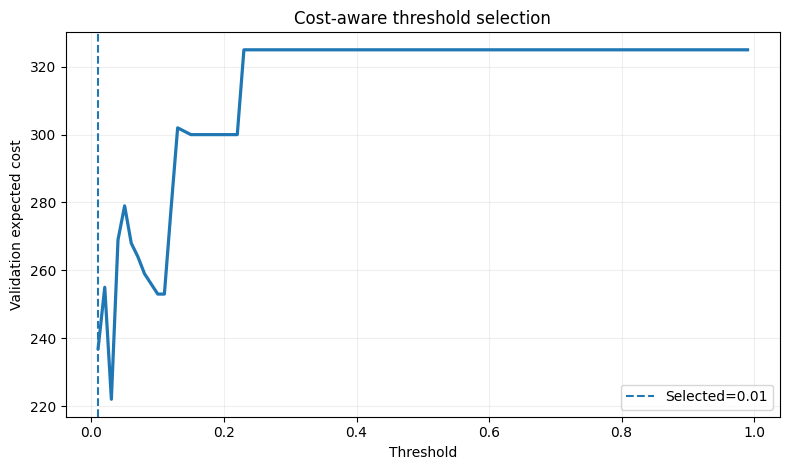

In [8]:
plt.figure(figsize=(8, 4.8))
plt.plot(validation_sweep["threshold"], validation_sweep["cost"], linewidth=2.3)
plt.axvline(threshold, linestyle="--", label=f"Selected={threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Validation expected cost")
plt.title("Cost-aware threshold selection")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "threshold_cost.png", dpi=160)
plt.show()

## Final test evaluation

The model and threshold are now frozen.

In [9]:
p_test = model.predict_proba(test[FEATURE_COLUMNS])[:, 1]
y_test = test["is_p1"].to_numpy()
pred_test = (p_test >= threshold).astype(int)

threshold_metrics = binary_metrics(y_test, pred_test)
metrics = {
    "positive_prevalence": float(np.mean(y_test)),
    "threshold": threshold,
    "roc_auc": float(roc_auc_score(y_test, p_test)),
    "average_precision": float(average_precision_score(y_test, p_test)),
    "log_loss": float(log_loss(y_test, p_test)),
    "brier_score": float(brier_score_loss(y_test, p_test)),
    "expected_calibration_error": float(expected_calibration_error(y_test, p_test)),
    **threshold_metrics,
    "alerts": int(pred_test.sum()),
    "alert_rate": float(pred_test.mean()),
    "expected_cost": float(threshold_metrics["fp"] + 25.0 * threshold_metrics["fn"]),
}
print(json.dumps(metrics, indent=2))
(REPORTS / "test_metrics.json").write_text(json.dumps(metrics, indent=2) + "\n")

{
  "positive_prevalence": 0.025,
  "threshold": 0.01,
  "roc_auc": 0.7482193732193732,
  "average_precision": 0.1331129480821624,
  "log_loss": 0.1052686593099199,
  "brier_score": 0.023459682564905916,
  "expected_calibration_error": 0.001902648143151317,
  "accuracy": 0.40208333333333335,
  "precision": 0.03389830508474576,
  "recall": 0.8333333333333334,
  "specificity": 0.391025641025641,
  "f1": 0.06514657980456026,
  "tn": 183.0,
  "fp": 285.0,
  "fn": 2.0,
  "tp": 10.0,
  "alerts": 295,
  "alert_rate": 0.6145833333333334,
  "expected_cost": 335.0
}


563

## Confusion matrix

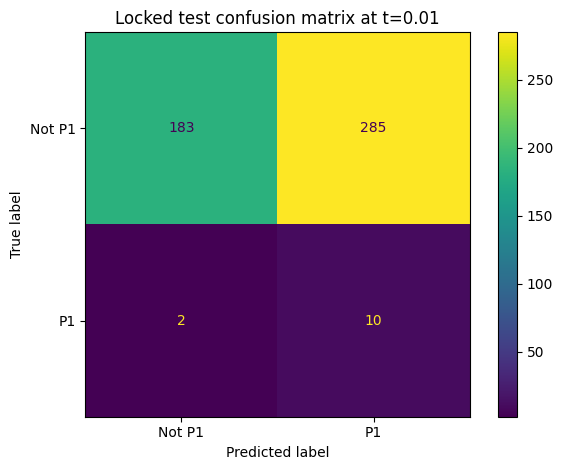

In [10]:
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not P1", "P1"])
disp.plot(values_format="d")
plt.title(f"Locked test confusion matrix at t={threshold:.2f}")
plt.tight_layout()
plt.savefig(ASSETS / "test_confusion_matrix.png", dpi=160)
plt.show()

## Discrimination curves

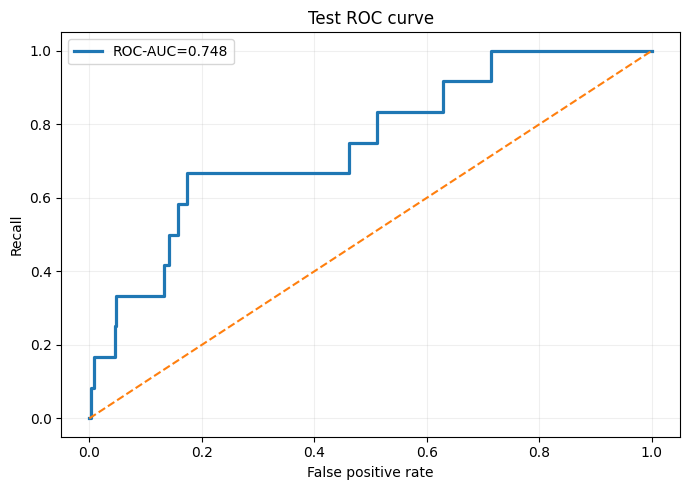

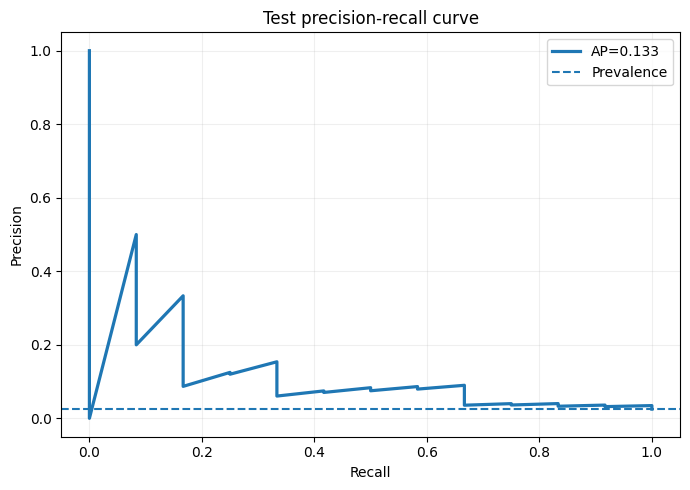

In [11]:
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2.3, label=f"ROC-AUC={metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("Recall")
plt.title("Test ROC curve")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "test_roc_curve.png", dpi=160)
plt.show()

precision, recall, _ = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2.3, label=f"AP={metrics['average_precision']:.3f}")
plt.axhline(np.mean(y_test), linestyle="--", label="Prevalence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test precision-recall curve")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "test_pr_curve.png", dpi=160)
plt.show()

## Calibration

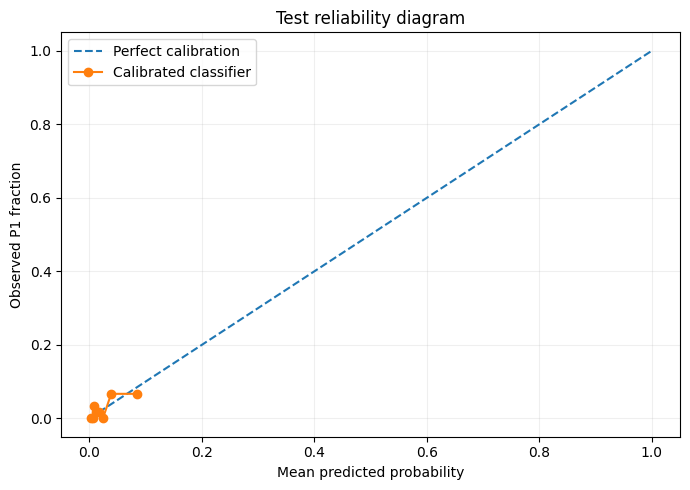

In [12]:
observed, predicted = calibration_curve(y_test, p_test, n_bins=8, strategy="quantile")
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(predicted, observed, marker="o", label="Calibrated classifier")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed P1 fraction")
plt.title("Test reliability diagram")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "test_reliability.png", dpi=160)
plt.show()

## Segment performance by service criticality

In [13]:
segment_rows = []
for criticality, group in test.assign(probability=p_test, prediction=pred_test).groupby("service_criticality"):
    if group["is_p1"].nunique() < 2:
        auc = np.nan
        ap = np.nan
    else:
        auc = roc_auc_score(group["is_p1"], group["probability"])
        ap = average_precision_score(group["is_p1"], group["probability"])
    row = binary_metrics(group["is_p1"].to_numpy(), group["prediction"].to_numpy())
    row.update(
        {
            "service_criticality": int(criticality),
            "n": int(len(group)),
            "prevalence": float(group["is_p1"].mean()),
            "roc_auc": float(auc) if np.isfinite(auc) else np.nan,
            "average_precision": float(ap) if np.isfinite(ap) else np.nan,
        }
    )
    segment_rows.append(row)

segment_metrics = pd.DataFrame(segment_rows)
segment_metrics.to_csv(REPORTS / "segment_metrics.csv", index=False)
segment_metrics[["service_criticality", "n", "prevalence", "precision", "recall", "fp", "fn"]]

,service_criticality,n,prevalence,precision,recall,fp,fn
0,1,94,0.010638,0.000000,0.0,23.0,1.0
1,2,102,0.009804,0.022222,1.0,44.0,0.0
2,3,88,0.011364,0.020408,1.0,48.0,0.0
3,4,99,0.020202,0.012048,0.5,82.0,1.0
4,5,97,0.072165,0.073684,1.0,88.0,0.0


## Error review samples

These rows are examples for structured qualitative review, not explanations of causality.

In [14]:
review = test.assign(probability=p_test, prediction=pred_test)
false_negatives = review[(review["is_p1"] == 1) & (review["prediction"] == 0)].sort_values("probability")
false_positives = review[(review["is_p1"] == 0) & (review["prediction"] == 1)].sort_values("probability", ascending=False)

print("False negatives:")
print(false_negatives[["incident_id", "timestamp", *FEATURE_COLUMNS, "probability"]].head(10))
print("\nFalse positives:")
print(false_positives[["incident_id", "timestamp", *FEATURE_COLUMNS, "probability"]].head(10))

False negatives:
     incident_id           timestamp  ...  monitoring_confidence  probability
2214  INC-002215 2024-10-03 18:00:00  ...                0.83627     0.007689
2054  INC-002055 2024-09-13 18:00:00  ...                0.91465     0.009316

[2 rows x 11 columns]

False positives:
     incident_id           timestamp  ...  monitoring_confidence  probability
2280  INC-002281 2024-10-12 00:00:00  ...                0.50443     0.260973
2360  INC-002361 2024-10-22 00:00:00  ...                0.66508     0.164361
2106  INC-002107 2024-09-20 06:00:00  ...                0.83726     0.156991
2045  INC-002046 2024-09-12 15:00:00  ...                0.67373     0.153308
2188  INC-002189 2024-09-30 12:00:00  ...                0.63468     0.128867
2389  INC-002390 2024-10-25 15:00:00  ...                0.73430     0.124779
2396  INC-002397 2024-10-26 12:00:00  ...                0.49441     0.107646
2038  INC-002039 2024-09-11 18:00:00  ...                0.61195     0.107448
2112  

## Final recommendation

Approve shadow mode only. Require stable live recall, manageable alert volume, acceptable calibration, segment review, human override, standard-workflow fallback, audit logs, and rollback before expanding the pilot.